# Common stuff
### based on QCD on the Lattice Ch. 3.3

In [37]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import tools
from scipy.optimize import curve_fit


# Wilson Loop
### based on ch. 3.4 and 3.5

In [38]:
with h5py.File("../../h5/Wilson562.h5", "r") as f:
    f.visit(print)

Configuration
Configuration/0
Configuration/0/T0
Configuration/0/T0/loops
Configuration/0/T0/r
Configuration/0/T1
Configuration/0/T1/loops
Configuration/0/T1/r
Configuration/0/T2
Configuration/0/T2/loops
Configuration/0/T2/r
Configuration/0/T3
Configuration/0/T3/loops
Configuration/0/T3/r
Configuration/0/T4
Configuration/0/T4/loops
Configuration/0/T4/r
Configuration/1
Configuration/1/T0
Configuration/1/T0/loops
Configuration/1/T0/r
Configuration/1/T1
Configuration/1/T1/loops
Configuration/1/T1/r
Configuration/1/T2
Configuration/1/T2/loops
Configuration/1/T2/r
Configuration/1/T3
Configuration/1/T3/loops
Configuration/1/T3/r
Configuration/1/T4
Configuration/1/T4/loops
Configuration/1/T4/r
Configuration/10
Configuration/10/T0
Configuration/10/T0/loops
Configuration/10/T0/r
Configuration/10/T1
Configuration/10/T1/loops
Configuration/10/T1/r
Configuration/10/T2
Configuration/10/T2/loops
Configuration/10/T2/r
Configuration/10/T3
Configuration/10/T3/loops
Configuration/10/T3/r
Configuration/1

In [122]:
# dimensionen machen murks..
def bootstrap(iterations, data):

    n = data.shape[0]

    indices = np.random.randint(0, n, size=(iterations, n))
    boot_samples = data[indices]       

    boot_means = np.mean(boot_samples, axis=1) 

    mean = np.mean(boot_means, axis=0)
    std  = np.std(boot_means, axis=0)

    return mean, std

In [181]:
def read_wilson_loops(filename, B, path = "Configuration", data_name = "loops"):

    all_data = []

    with h5py.File(filename, "r") as f:

        config_keys = list(f[path].keys())

        for cfg in config_keys: 

            T_keys = list(f[f"{path}/{cfg}"].keys())
            cfg_data = []

            for T in T_keys:

                data = f[f"{path}/{cfg}/{T}/{data_name}"][:]
                cfg_data.append(data)

            all_data.append(cfg_data)

    all_data = np.array(all_data)
    means = []
    stds = []

    for r in range(all_data.shape[2]):

        means_r = []
        stds_r = []

        for nt in range(all_data.shape[1]):

            data = all_data[:, nt, r]
            #print("Shape of data:", data.shape)
            #print(all_data.shape)
            #print(all_data[0][0].shape)
            mean, std = bootstrap(B, data)

            means_r.append(mean)
            stds_r.append(std)
        
        means.append(means_r)
        stds.append(stds_r)
    return np.array(means), np.array(stds)
    

In [182]:
means, stds = read_wilson_loops(
    filename="../../h5/Wilson562.h5",
    B=200
)

In [194]:
print(means[:,0])

[[ 0.29899391  0.01975523]
 [ 0.00605075 -0.0052469 ]
 [ 0.00302877 -0.03266313]
 [-0.01252798  0.02390181]
 [ 0.00037798 -0.03159995]]


### Fit for $a V(an)$ and $C$, with $aV(an)=A+\frac{B}{n} + \sigma n$

In [184]:
W_data = means[:, :, 0]
N_r, N_t = W_data.shape

n_values = np.arange(1, W_data.shape[0]+1)
t_values = np.arange(1, W_data.shape[1]+1)
print(t_values)

[1 2 3 4 5]


In [185]:
def wilson_loop_exp(n, t, C, Aa, B, sigmaa2):
    
    aV = Aa + B / n + sigmaa2 * n

    return C * np.exp(-t * aV)


In [186]:
# probiere den lachs mal als log
def wilson_loop_log(n, t, lnC, Aa, B, sigmaa2):
    
    aV = Aa + B / n + sigmaa2 * n

    return lnC -t * aV


In [187]:
# dimensionen machen murks die zweite...
N, T = np.meshgrid(n_values, t_values, indexing='ij')
x_data = np.vstack([N.ravel(), T.ravel()])
y_data = W_data.ravel()
y_data_log = np.log(np.where(W_data[:, :] <= 0, 1e-15, W_data[:, :])).ravel()

def fit_func(X, C, Aa, B, sigmaa2):
    
    n, t = X
    #print(t)
    
    return wilson_loop_exp(n, t, C, Aa, B, sigmaa2)

def fit_func_log(X, lnC, Aa, B, sigmaa2):
    
    n, t = X
    
    return wilson_loop_log(n, t, lnC, Aa, B, sigmaa2)


In [188]:
# fit fit fit
p0 =[1.0, 0, 0.5, 0.1]

popt, pcov = curve_fit(fit_func, x_data, y_data, p0=p0)
C_fit, Aa_fit, B_fit, sigma_a2 = popt

print(C_fit)
print(Aa_fit)
print(B_fit)
print(sigma_a2)

0.33670355298683086
2.034938551324937
-4.032343111515155
2.021317327524986


In [189]:
# fit log
#popt, pcov = curve_fit(fit_func_log, x_data, y_data_log, p0=p0)

#lnC_fit, Aa_fit, B_fit, sigma_a2 = popt
#C_fit_new = np.exp(lnC_fit)


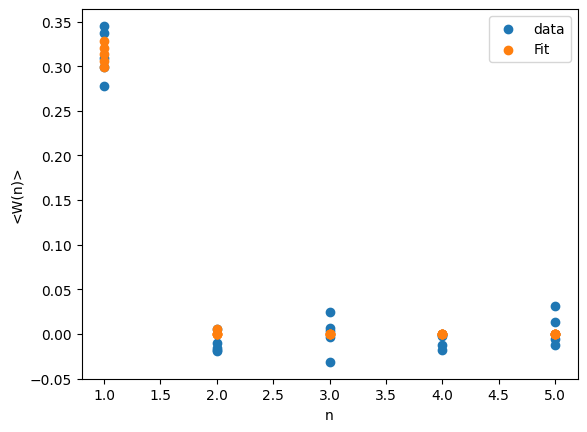

In [190]:

W_fit = (wilson_loop_exp(N, T, *popt))

plt.figure()
plt.scatter(N.ravel(), W_data.ravel(), label='data')
plt.scatter(N.ravel(), W_fit.ravel(), label='Fit')
plt.xlabel("n")
plt.ylabel("<W(n)>")
plt.legend()
plt.show()

### Get Sommer parameter and lattice spacing

In [191]:
r0_a = np.sqrt((1.65 + B_fit) / (sigma_a2))
print(r0_a)

nan


/var/folders/r9/27_dhc4x34jgk78x3g0gkg7w0000gn/T/ipykernel_1352/3203018957.py:1: RuntimeWarning: invalid value encountered in sqrt
  r0_a = np.sqrt((1.65 + B_fit) / (sigma_a2))


In [192]:
r0_phys = 0.5 #fm
a = r0_phys / r0_a
print(a)

nan


In [193]:
# something is very wrong...

# Polyakov Loop
### based on ch. 4.5.4